In [85]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install statsmodels
%pip install scikit-learn
%pip install prophet


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgr

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
from statsmodels.tsa.seasonal import STL

In [87]:
import os

file_path = "../data/processed/Delay_rate_by_month.csv"

if not os.path.exists(file_path):
    print(f"Error: The File '{file_path}' does not exist ")
else:
    try:
        df = pd.read_csv(
            file_path,
            on_bad_lines ="skip",
            encoding = 'utf-8'
        )
        print("CSV loaded successfully")
        print(df.head())
    except pd.errors.EmptyDataError:
        print("Error: The CSV is empty")
    except pd.errors.ParserError as e:
        print(f"Error: Parse error (structrally corrupt CSV) {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        

CSV loaded successfully
     month  delivered_orders  delayed_orders  delay_rate
0  2019-01              6065             605         9.0
1  2019-02              6163             578         9.0
2  2019-03              6435             660        10.0
3  2019-04              6067             606         9.0
4  2019-05             10329            1017         9.0


In [88]:
df.head()

,month,delivered_orders,delayed_orders,delay_rate
0,2019-01,6065,605,9.0
1,2019-02,6163,578,9.0
2,2019-03,6435,660,10.0
3,2019-04,6067,606,9.0
4,2019-05,10329,1017,9.0


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             84 non-null     str    
 1   delivered_orders  84 non-null     int64  
 2   delayed_orders    84 non-null     int64  
 3   delay_rate        84 non-null     float64
dtypes: float64(1), int64(2), str(1)
memory usage: 2.8 KB


In [90]:
df.isna().sum()

month               0
delivered_orders    0
delayed_orders      0
delay_rate          0
dtype: int64

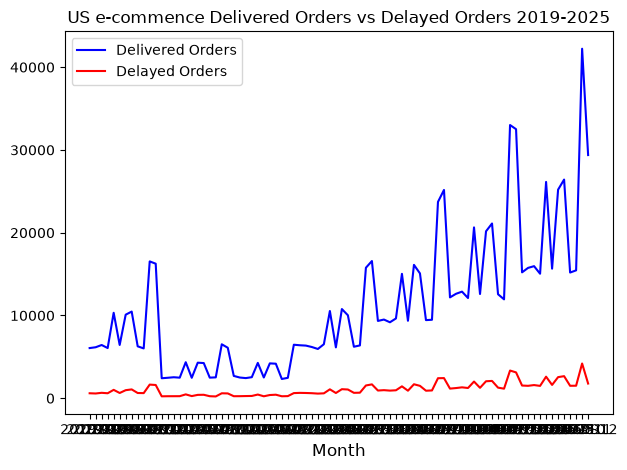

In [91]:
plt.Figure(figsize=(12,8))
plt.plot(df['month'],df['delivered_orders'],color='blue',linestyle='-',label='Delivered Orders')
plt.plot(df['month'],df['delayed_orders'],color='red',linestyle='-',label='Delayed Orders')
plt.title('US e-commence Delivered Orders vs Delayed Orders 2019-2025')
plt.xlabel('Month',fontsize = 12)
plt.legend()


plt.tight_layout()
plt.show()

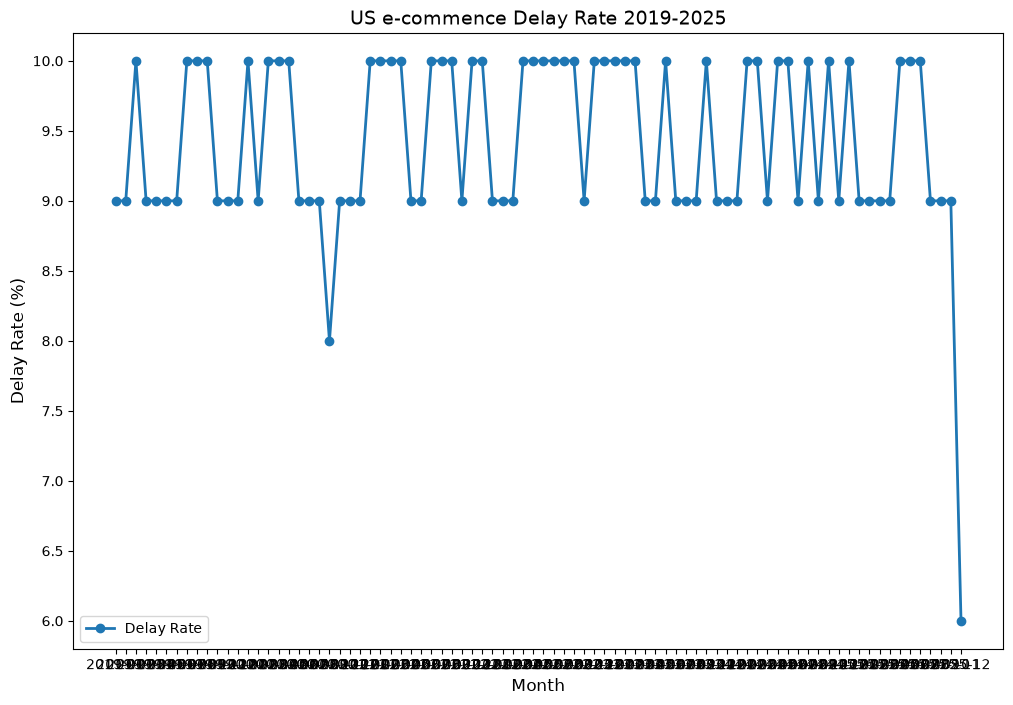

In [92]:
plt.figure(figsize=(12,8))
plt.plot(df['month'],df['delay_rate'],marker='o', linewidth=2, label='Delay Rate')

plt.title('US e-commence Delay Rate 2019-2025',fontsize=14)
plt.xlabel('Month',fontsize=12)
plt.ylabel('Delay Rate (%)',fontsize=12)
plt.legend()

plt.show()

In [93]:
df = df.copy()
df['month'] = pd.to_datetime(df['month'],format='%Y-%m')
df.set_index('month',inplace=True)
res = STL(df['delay_rate'],period=12, robust = True).fit()

residuals = res.resid

z_scores = (residuals - residuals.mean())/residuals.std()

outliers = df[np.abs(z_scores) > 3]
print('Confirmed Outliers :')
print(outliers)

Confirmed Outliers :
            delivered_orders  delayed_orders  delay_rate
month                                                   
2020-10-01              2526             221         8.0


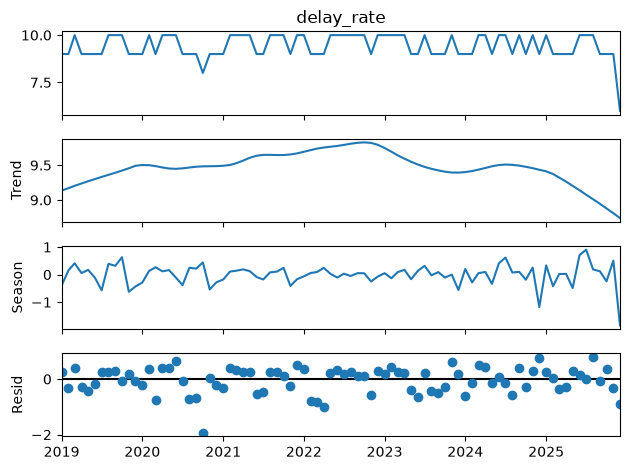

In [94]:
res.plot()
plt.show()

From the resid graph to see, the final data point (one of the outliers in the original) is not shown as the outlier. I try to replace it with the datapoint at the same location at the previous period.

In [95]:
# Last data point is highly the glitch or error. Due to the features of the STL model, it cannot detect the outlier at the end of the dataset
df.iloc[-1, df.columns.get_loc('delay_rate')] = df.iloc[-13]['delay_rate']


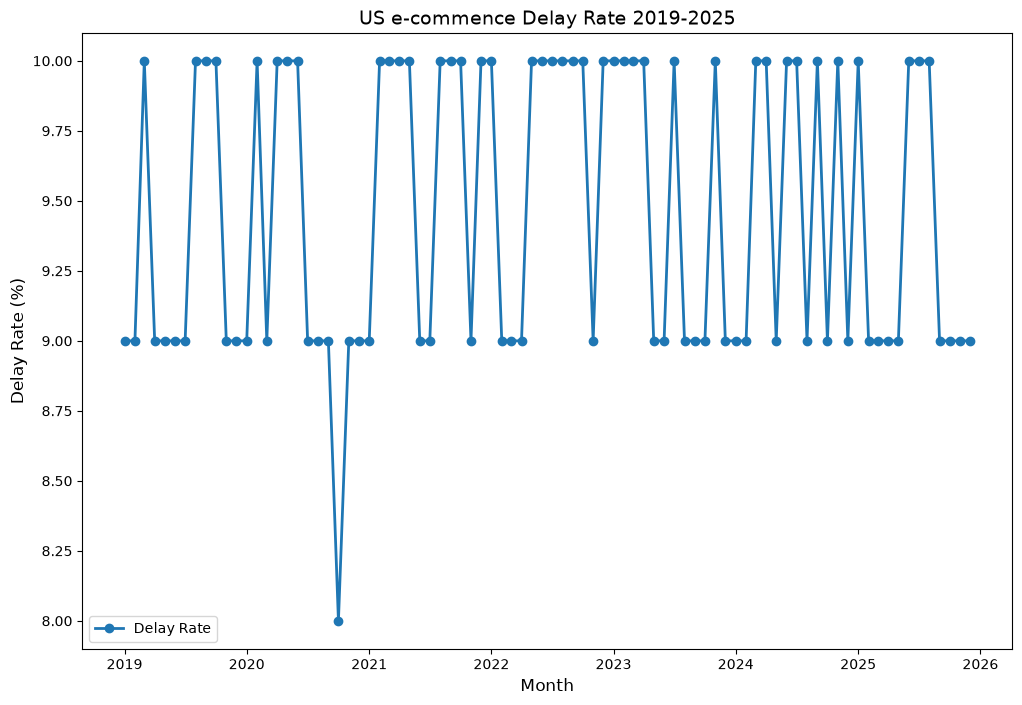

In [96]:
plt.figure(figsize=(12,8))
plt.plot(df.index,df['delay_rate'],marker='o', linewidth=2, label='Delay Rate')

plt.title('US e-commence Delay Rate 2019-2025',fontsize=14)
plt.xlabel('Month',fontsize=12)
plt.ylabel('Delay Rate (%)',fontsize=12)
plt.legend()

plt.show()

In [97]:
res = STL(df['delay_rate'],period=12, robust = True).fit()

residuals = res.resid

z_scores = (residuals - residuals.mean())/residuals.std()

outliers = df[np.abs(z_scores) > 3]
print('Confirmed Outliers :')
print(outliers)

Confirmed Outliers :
            delivered_orders  delayed_orders  delay_rate
month                                                   
2020-10-01              2526             221         8.0


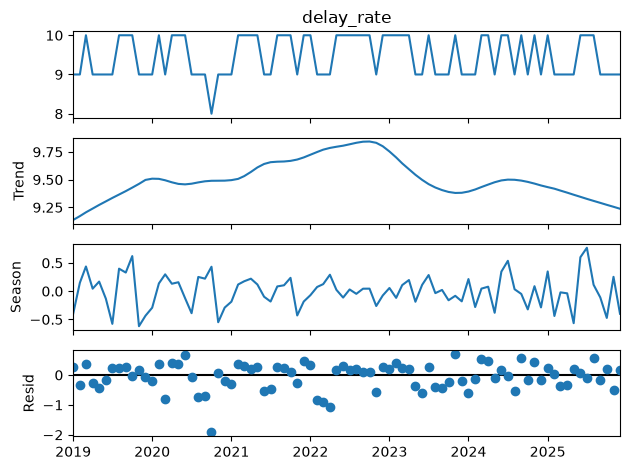

In [98]:
res.plot()
plt.show()

Time series Analysis 
Objective: to confirm the seasonality of the time series and assess the models' accuracy

/var/folders/17/n4pxy9ts2tl7x_nyffjzkc880000gn/T/ipykernel_17981/3210710546.py:2: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  result = seasonal_decompose(df['delay_rate'], model='multiplicative',extrapolate_trend='freq')


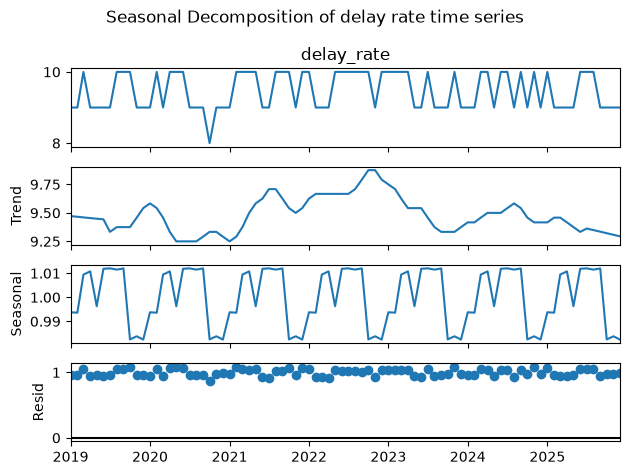

In [99]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['delay_rate'], model='multiplicative',extrapolate_trend='freq')
result.plot()
plt.suptitle('Seasonal Decomposition of delay rate time series')
plt.tight_layout()
plt.show()

Visually confirmed the seaonsonality

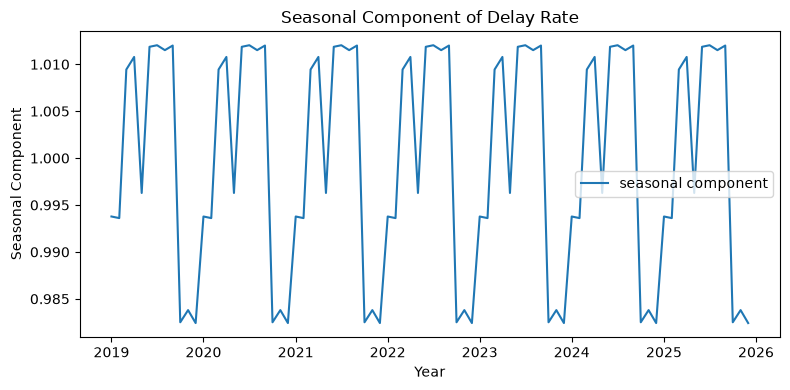

In [100]:
#Display Seasonlity graph
plt.figure(figsize=(8,4))
plt.plot(result.seasonal,label='seasonal component')
plt.title('Seasonal Component of Delay Rate')
plt.xlabel('Year')
plt.ylabel('Seasonal Component')
plt.legend()
plt.tight_layout()
plt.show()

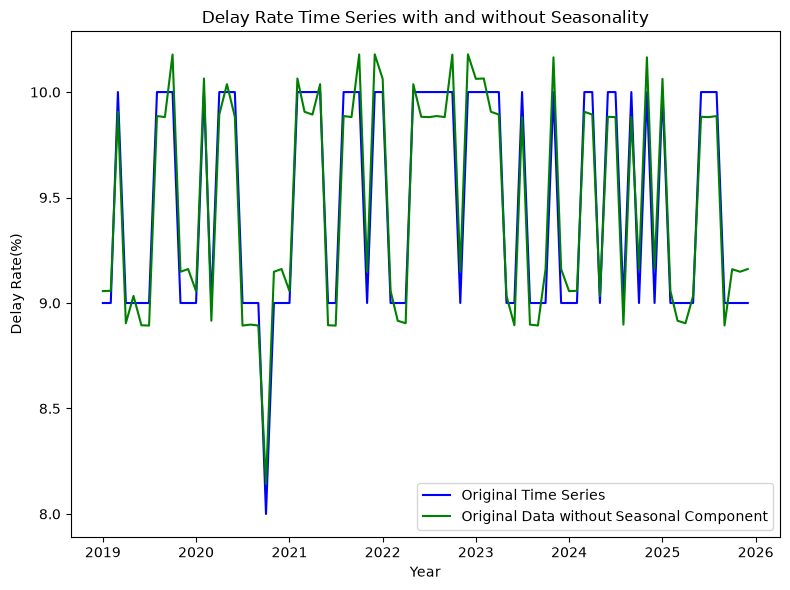

In [101]:
#plot the original data and origin data without the seasonal component
plt.figure(figsize=(8,6))
plt.plot(df['delay_rate'],label="Original Time Series",color='blue')
data_without_seasonal = df['delay_rate'] / result.seasonal
plt.plot(data_without_seasonal,label="Original Data without Seasonal Component",color='green')
plt.title('Delay Rate Time Series with and without Seasonality')
plt.xlabel('Year')
plt.ylabel('Delay Rate(%)')
plt.legend()
plt.tight_layout()
plt.show()


In [102]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(data_without_seasonal)

print('ADF statistic:', adf_result[0])
print('p-value', adf_result[1])

if adf_result[1] < 0.05:
    print("The data is stationary (p-value < 0.05)")
else:
    print('The data is not stationary (p-value >= 0.05)')

ADF statistic: -7.438695257082195
p-value 6.086335714297373e-11
The data is stationary (p-value < 0.05)


/var/folders/17/n4pxy9ts2tl7x_nyffjzkc880000gn/T/ipykernel_17981/325816308.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(data_without_seasonal)


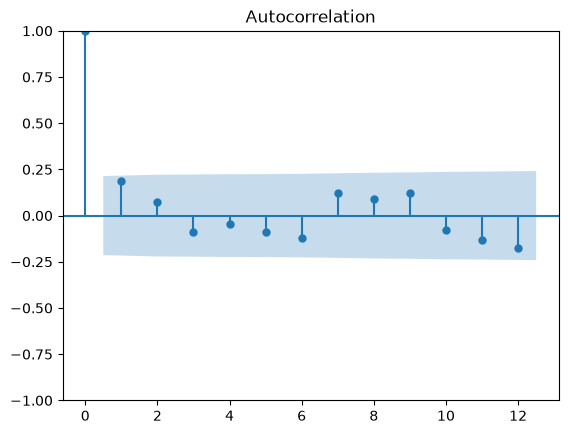

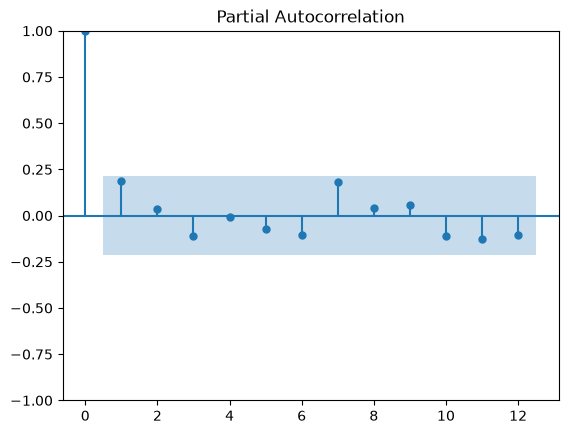

In [103]:
#find p and q
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

plot_acf(data_without_seasonal,lags=12)
plot_pacf(data_without_seasonal,lags=12)
plt.show()

In [104]:
split_idx = int(len(data_without_seasonal) * 0.8)
train = data_without_seasonal.iloc[:split_idx]
test = data_without_seasonal.iloc[split_idx:]


In [105]:
#Visually confirmed p = 1 and q = 1
#fit ARMA model
from statsmodels.tsa.arima.model import ARIMA
p = 1
d = 0
q = 1
arma = ARIMA(train, order=(p,d,q))
arma_fit = arma.fit()

print(arma_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   67
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -49.126
Date:                Wed, 23 Sep 2026   AIC                            106.252
Time:                        17:29:56   BIC                            115.070
Sample:                    01-01-2019   HQIC                           109.741
                         - 07-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.4885      0.082    116.007      0.000       9.328       9.649
ar.L1          0.1833      0.519      0.353      0.724      -0.833       1.200
ma.L1          0.0684      0.545      0.125      0.9

/Users/alex/delivery-delay-analysis/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/alex/delivery-delay-analysis/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


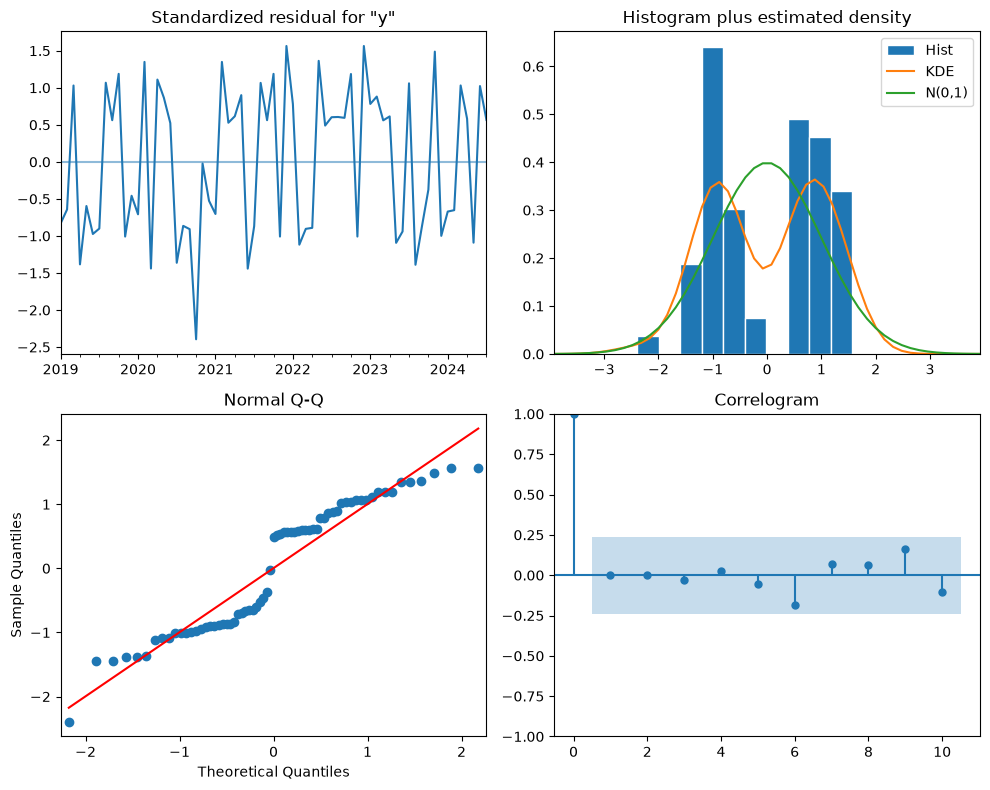

In [106]:
arma_fit.plot_diagnostics(figsize=(10,8))
plt.tight_layout()
plt.show()

In [107]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error

forecast = arma_fit.forecast(steps=len(test))

mae = mean_absolute_error(test,forecast)
rmse = root_mean_squared_error(test,forecast)
mape = mean_absolute_percentage_error(test,forecast)

print(f'Mean absolute error(MAE): {mae:.4f}')
print(f'Root mean squared error (RMSE):{rmse:.4f}')
print(f'Mean Absolute Percentage of Error (MAPE): {mape * 100:.2f}%')

Mean absolute error(MAE): 0.4580
Root mean squared error (RMSE):0.4744
Mean Absolute Percentage of Error (MAPE): 4.90%


MAE, RMSE and MAPE are quite low. The accuracy of model is high. The ARMA model is fit for the this time series dataset.

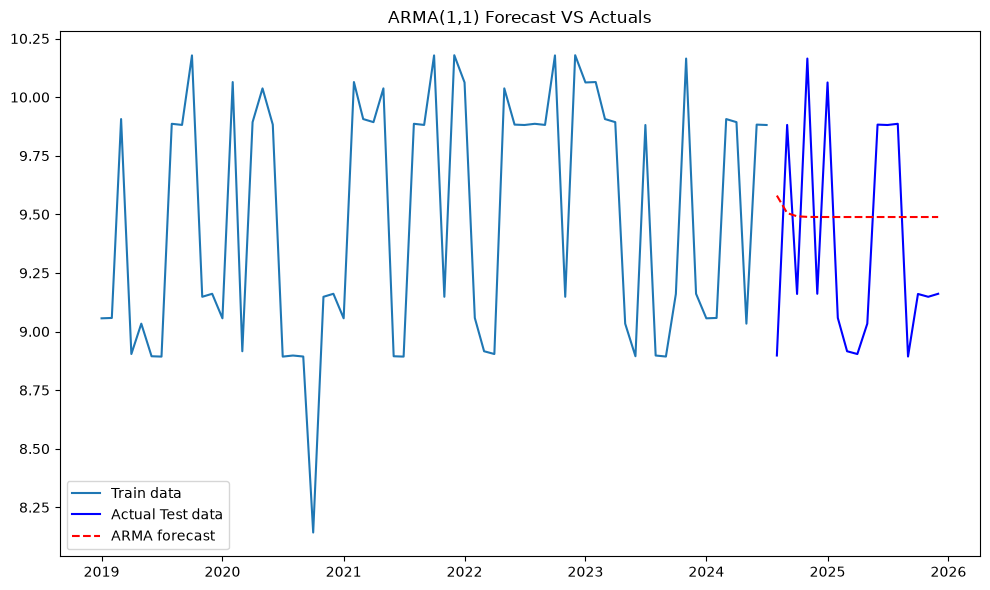

In [108]:
plt.figure(figsize=(10,6))
plt.plot(train.index, train, label = "Train data")
plt.plot(test.index, test, label="Actual Test data", color="blue")
plt.plot(test.index,forecast,label="ARMA forecast",color="red",linestyle="--")
plt.title(f"ARMA({p},{q}) Forecast VS Actuals")
plt.legend()
plt.tight_layout()
plt.show()
